In [1]:
from pathlib import Path
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_DIR = Path("/home/ganchao/Desktop/traj_decoding/trajectory-decoding")
sys.path.insert(0, str(REPO_DIR))

DATASETS = {
    # "raw": {
    #     "data_dir": REPO_DIR / "data/m96z_calltype/m96z_U331_uma_raw",
    #     "ckpt_dir": REPO_DIR / "checkpoints/m96z_U331_uma_raw_fast",
    #     "ae_log": REPO_DIR / "logs/m96z_U331_uma_raw_fast_ae.log",
    #     "svm_log": REPO_DIR / "logs/m96z_U331_uma_raw_fast_svm.log",
    # },
    # "smooth": {
    #     "data_dir": REPO_DIR / "data/m96z_calltype/m96z_U331_uma_smooth_sigma5",
    #     "ckpt_dir": REPO_DIR / "checkpoints/m96z_U331_uma_smooth_sigma5_fast",
    #     "ae_log": REPO_DIR / "logs/m96z_U331_uma_smooth_sigma5_fast_ae.log",
    #     "svm_log": REPO_DIR / "logs/m96z_U331_uma_smooth_sigma5_fast_svm.log",
    # },
    "smooth_z": {
        "data_dir": REPO_DIR / "data/m96z_calltype/m96z_U331_uma_smooth_sigma5_z",
        "ckpt_dir": REPO_DIR / "checkpoints/m96z_U331_uma_smooth_sigma5_z_fast",
        "ae_log": REPO_DIR / "logs/m96z_U331_uma_smooth_sigma5_z_fast_ae.log",
        "svm_log": REPO_DIR / "logs/m96z_U331_uma_smooth_sigma5_z_fast_svm.log",
    },
}

D_MODEL = 32
N_LAYERS = 1
D_STATE = 16

for name, cfg in DATASETS.items():
    print(name)
    for k, p in cfg.items():
        print(f"  {k:8s}", p.exists(), p)

smooth_z
  data_dir True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data/m96z_calltype/m96z_U331_uma_smooth_sigma5_z
  ckpt_dir True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/checkpoints/m96z_U331_uma_smooth_sigma5_z_fast
  ae_log   True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/logs/m96z_U331_uma_smooth_sigma5_z_fast_ae.log
  svm_log  True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/logs/m96z_U331_uma_smooth_sigma5_z_fast_svm.log


In [2]:
def parse_ts_file(path):
    path = Path(path)
    text = path.read_text(errors="ignore")

    class_names = None
    X = []
    y = []
    in_data = False

    for line in text.splitlines():
        line = line.strip()

        if len(line) == 0 or line.startswith("#"):
            continue

        if line.lower().startswith("@classlabel"):
            parts = line.split()
            class_names = parts[2:]
            class_to_id = {c: i for i, c in enumerate(class_names)}
            continue

        if line.lower().startswith("@data"):
            in_data = True
            continue

        if line.startswith("@") or not in_data:
            continue

        parts = line.split(":")
        label = parts[-1].strip()
        dim_parts = parts[:-1]

        dims = []
        for dp in dim_parts:
            vals = [float(v) for v in dp.split(",") if v != ""]
            dims.append(vals)

        X.append(np.asarray(dims, dtype=np.float32).T)
        y.append(class_to_id[label])

    return np.stack(X), np.asarray(y, dtype=np.int64), class_names

def load_ts_dataset(data_dir):
    data_dir = Path(data_dir)

    train_files = sorted(data_dir.glob("*_TRAIN.ts"))
    assert len(train_files) == 1, f"Expected one TRAIN file in {data_dir}, found {len(train_files)}"

    train_path = train_files[0]
    test_path = train_path.with_name(train_path.name.replace("_TRAIN.ts", "_TEST.ts"))

    assert test_path.exists(), f"Missing TEST file: {test_path}"

    X_train, y_train, class_names_train = parse_ts_file(train_path)
    X_test, y_test, class_names_test = parse_ts_file(test_path)

    assert class_names_train == class_names_test
    assert X_train.shape[1:] == X_test.shape[1:]

    return X_train, y_train, X_test, y_test, class_names_train

rows = []

for name, cfg in DATASETS.items():
    X_train, y_train, X_test, y_test, class_names = load_ts_dataset(cfg["data_dir"])

    rows.append({
        "dataset": name,
        "X_train": X_train.shape,
        "X_test": X_test.shape,
        "y_train": y_train.shape,
        "y_test": y_test.shape,
        "classes": class_names,
    })

shape_df = pd.DataFrame(rows)
display(shape_df)

,dataset,X_train,X_test,y_train,y_test,classes
0,smooth_z,"(160, 1441, 32)","(40, 1441, 32)","(160,)","(40,)","[phee, twitter, trill, trill_phee]"


In [3]:
count_rows = []

for name, cfg in DATASETS.items():
    X_train, y_train, X_test, y_test, class_names = load_ts_dataset(cfg["data_dir"])

    for k, cls in enumerate(class_names):
        count_rows.append({
            "dataset": name,
            "class": cls,
            "train": int(np.sum(y_train == k)),
            "test": int(np.sum(y_test == k)),
        })

count_df = pd.DataFrame(count_rows)
display(count_df)

,dataset,class,train,test
0,smooth_z,phee,40,10
1,smooth_z,twitter,40,10
2,smooth_z,trill,40,10
3,smooth_z,trill_phee,40,10


In [4]:
def parse_ae_log(path):
    rows = []

    if not path.exists():
        return pd.DataFrame(columns=["epoch", "total_epochs", "loss"])

    text = path.read_text(errors="ignore")

    for m in re.finditer(r"Epoch\s+(\d+)/(\d+)\s+loss=([0-9.eE+-]+)", text):
        rows.append({
            "epoch": int(m.group(1)),
            "total_epochs": int(m.group(2)),
            "loss": float(m.group(3)),
        })

    return pd.DataFrame(rows)

def parse_svm_log(path):
    if not path.exists():
        return np.nan, np.nan, np.nan

    text = path.read_text(errors="ignore")
    m = re.search(r"\[SVM\]\s+Test accuracy:\s+([0-9.]+)\s+\((\d+)/(\d+)\)", text)

    if m is None:
        return np.nan, np.nan, np.nan

    return float(m.group(1)), int(m.group(2)), int(m.group(3))

summary_rows = []
loss_dfs = {}

for name, cfg in DATASETS.items():
    loss_df = parse_ae_log(cfg["ae_log"])
    loss_dfs[name] = loss_df

    acc, correct, total = parse_svm_log(cfg["svm_log"])

    summary_rows.append({
        "dataset": name,
        "ae_epochs_logged": len(loss_df),
        "ae_first_loss": loss_df["loss"].iloc[0] if len(loss_df) else np.nan,
        "ae_last_loss": loss_df["loss"].iloc[-1] if len(loss_df) else np.nan,
        "svm_acc_from_log": acc,
        "svm_correct": correct,
        "svm_total": total,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,dataset,ae_epochs_logged,ae_first_loss,ae_last_loss,svm_acc_from_log,svm_correct,svm_total
0,smooth_z,6,1.196307,0.783382,0.475,19,40


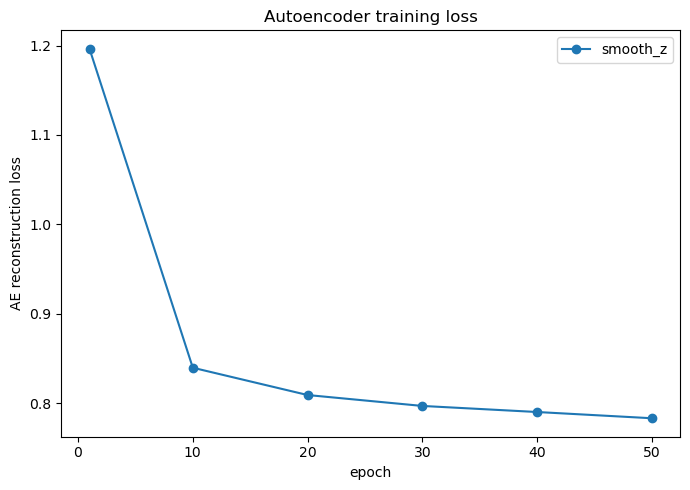

In [5]:
plt.figure(figsize=(7, 5))

for name, loss_df in loss_dfs.items():
    if len(loss_df) == 0:
        continue

    plt.plot(loss_df["epoch"], loss_df["loss"], marker="o", label=name)

plt.xlabel("epoch")
plt.ylabel("AE reconstruction loss")
plt.title("Autoencoder training loss")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import torch
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

from src.model import SequenceEncoder, SequenceAutoencoder, masked_mse_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

class LocalTrajectoryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.X[idx].shape[0], self.y[idx]

def local_collate_fn(batch):
    seqs, lengths, labels = zip(*batch)
    lengths = torch.tensor(lengths, dtype=torch.int64)
    padded = pad_sequence(list(seqs), batch_first=True)
    labels = torch.stack(labels)
    return padded, lengths, labels

@torch.no_grad()
def extract_embeddings(encoder, X, y, batch_size=16):
    loader = DataLoader(
        LocalTrajectoryDataset(X, y),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=local_collate_fn,
    )

    Zs = []
    ys = []

    encoder.eval()

    for seqs, lengths, labels in loader:
        seqs = seqs.to(device)
        lengths = lengths.to(device)

        z = encoder(seqs, lengths)

        Zs.append(z.cpu().numpy())
        ys.append(labels.numpy())

    return np.concatenate(Zs, axis=0), np.concatenate(ys, axis=0)

@torch.no_grad()
def reconstruction_mse(model, X, y, batch_size=8):
    loader = DataLoader(
        LocalTrajectoryDataset(X, y),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=local_collate_fn,
    )

    losses = []

    model.eval()

    for seqs, lengths, labels in loader:
        seqs = seqs.to(device)
        lengths = lengths.to(device)

        x_hat, z = model(seqs, lengths)
        loss = masked_mse_loss(x_hat, seqs, lengths)

        losses.append(float(loss.cpu()))

    return float(np.mean(losses))

device: cuda


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

results = {}
eval_rows = []

for name, cfg in DATASETS.items():
    X_train, y_train, X_test, y_test, class_names = load_ts_dataset(cfg["data_dir"])

    input_dim = X_train.shape[-1]

    encoder = SequenceEncoder(
        input_dim=input_dim,
        d_model=D_MODEL,
        n_layers=N_LAYERS,
        d_state=D_STATE,
    ).to(device)

    enc_path = cfg["ckpt_dir"] / "encoder.pt"
    assert enc_path.exists(), f"Missing encoder checkpoint: {enc_path}"

    encoder.load_state_dict(torch.load(enc_path, map_location=device))
    encoder.eval()

    Z_train, ytr = extract_embeddings(encoder, X_train, y_train)
    Z_test, yte = extract_embeddings(encoder, X_test, y_test)

    scaler = StandardScaler()
    Z_train_s = scaler.fit_transform(Z_train)
    Z_test_s = scaler.transform(Z_test)

    clf = SVC(kernel="rbf", C=10.0, gamma="scale")
    clf.fit(Z_train_s, ytr)

    pred = clf.predict(Z_test_s)
    acc = accuracy_score(yte, pred)
    cm = confusion_matrix(yte, pred, labels=np.arange(len(class_names)))

    results[name] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "class_names": class_names,
        "encoder": encoder,
        "Z_train": Z_train,
        "Z_test": Z_test,
        "pred": pred,
        "cm": cm,
        "acc": acc,
    }

    eval_rows.append({
        "dataset": name,
        "svm_acc_recomputed": acc,
        "correct": int(np.sum(pred == yte)),
        "total": len(yte),
        "embedding_dim": Z_train.shape[1],
    })

eval_df = pd.DataFrame(eval_rows)
display(eval_df)

,dataset,svm_acc_recomputed,correct,total,embedding_dim
0,smooth_z,0.475,19,40,32


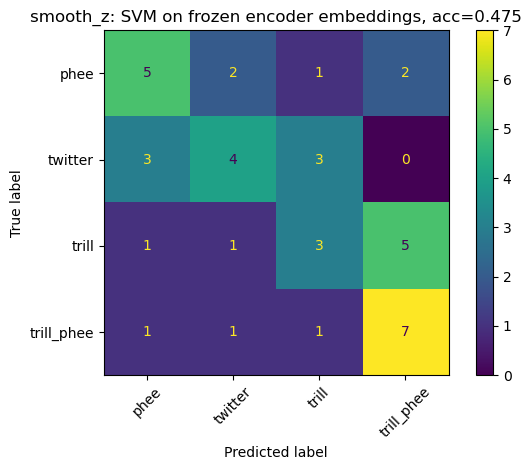

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, res in results.items():
    cm = res["cm"]
    class_names = res["class_names"]

    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)

    plt.title(f"{name}: SVM on frozen encoder embeddings, acc={res['acc']:.3f}")
    plt.tight_layout()
    plt.show()

In [9]:
for name, res in results.items():
    print()
    print("=" * 80)
    print(name)
    print("=" * 80)

    print(classification_report(
        res["y_test"],
        res["pred"],
        target_names=res["class_names"],
        zero_division=0,
    ))


smooth_z
              precision    recall  f1-score   support

        phee       0.50      0.50      0.50        10
     twitter       0.50      0.40      0.44        10
       trill       0.38      0.30      0.33        10
  trill_phee       0.50      0.70      0.58        10

    accuracy                           0.47        40
   macro avg       0.47      0.47      0.47        40
weighted avg       0.47      0.47      0.47        40



In [10]:
def pca_2d(Z):
    Z0 = Z - Z.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Z0, full_matrices=False)
    Z2 = U[:, :2] * S[:2]
    explained = S**2 / np.sum(S**2)
    return Z2, explained

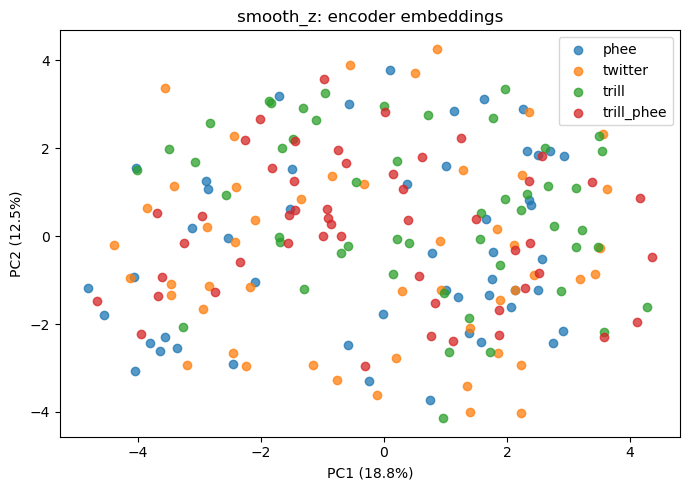

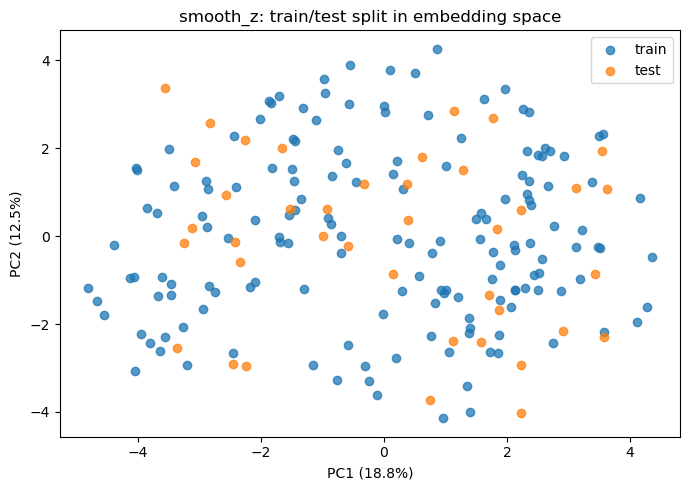

In [11]:
for name, res in results.items():
    Z_all = np.concatenate([res["Z_train"], res["Z_test"]], axis=0)
    y_all = np.concatenate([res["y_train"], res["y_test"]], axis=0)
    split = np.array(["train"] * len(res["y_train"]) + ["test"] * len(res["y_test"]))

    Z2, explained = pca_2d(Z_all)

    plt.figure(figsize=(7, 5))

    for k, cls in enumerate(res["class_names"]):
        mask = y_all == k
        plt.scatter(Z2[mask, 0], Z2[mask, 1], label=cls, alpha=0.75)

    plt.xlabel(f"PC1 ({explained[0]:.1%})")
    plt.ylabel(f"PC2 ({explained[1]:.1%})")
    plt.title(f"{name}: encoder embeddings")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))

    for s in ["train", "test"]:
        mask = split == s
        plt.scatter(Z2[mask, 0], Z2[mask, 1], label=s, alpha=0.75)

    plt.xlabel(f"PC1 ({explained[0]:.1%})")
    plt.ylabel(f"PC2 ({explained[1]:.1%})")
    plt.title(f"{name}: train/test split in embedding space")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [12]:
recon_rows = []

for name, cfg in DATASETS.items():
    X_train = results[name]["X_train"]
    y_train = results[name]["y_train"]
    X_test = results[name]["X_test"]
    y_test = results[name]["y_test"]

    input_dim = X_train.shape[-1]

    model = SequenceAutoencoder(
        input_dim=input_dim,
        d_model=D_MODEL,
        n_layers=N_LAYERS,
        d_state=D_STATE,
    ).to(device)

    ae_path = cfg["ckpt_dir"] / "autoencoder.pt"
    assert ae_path.exists(), f"Missing autoencoder checkpoint: {ae_path}"

    model.load_state_dict(torch.load(ae_path, map_location=device))
    model.eval()

    train_mse = reconstruction_mse(model, X_train, y_train)
    test_mse = reconstruction_mse(model, X_test, y_test)

    recon_rows.append({
        "dataset": name,
        "train_recon_mse": train_mse,
        "test_recon_mse": test_mse,
    })

recon_df = pd.DataFrame(recon_rows)
display(recon_df)

,dataset,train_recon_mse,test_recon_mse
0,smooth_z,0.783529,0.777337


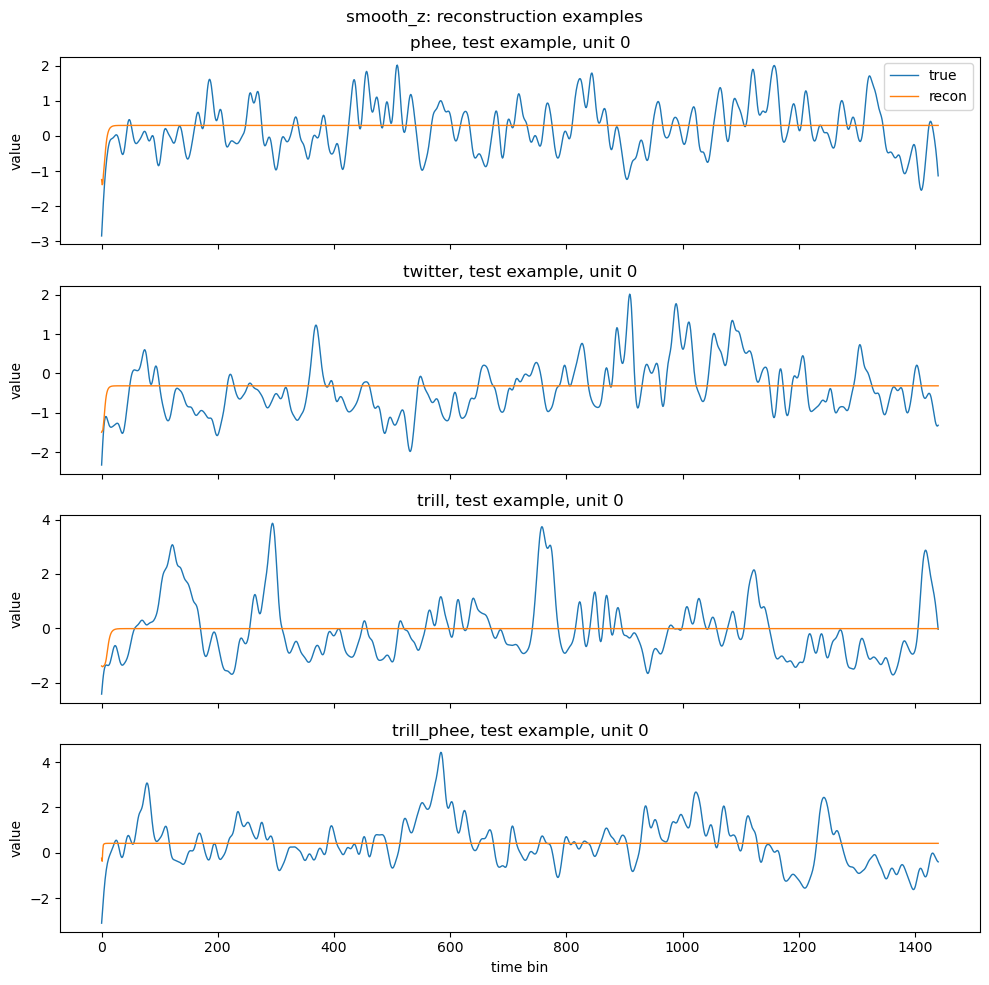

In [13]:
@torch.no_grad()
def reconstruct_one(model, x):
    model.eval()

    xb = torch.from_numpy(x[None].astype(np.float32)).to(device)
    lengths = torch.tensor([x.shape[0]], dtype=torch.int64).to(device)

    x_hat, z = model(xb, lengths)

    return x_hat[0].cpu().numpy()

for name, cfg in DATASETS.items():
    res = results[name]

    input_dim = res["X_train"].shape[-1]

    model = SequenceAutoencoder(
        input_dim=input_dim,
        d_model=D_MODEL,
        n_layers=N_LAYERS,
        d_state=D_STATE,
    ).to(device)

    model.load_state_dict(torch.load(cfg["ckpt_dir"] / "autoencoder.pt", map_location=device))
    model.eval()

    fig, axes = plt.subplots(len(res["class_names"]), 1, figsize=(10, 2.5 * len(res["class_names"])), sharex=True)

    if len(res["class_names"]) == 1:
        axes = [axes]

    for k, cls in enumerate(res["class_names"]):
        idx = np.where(res["y_test"] == k)[0][0]

        x = res["X_test"][idx]
        x_hat = reconstruct_one(model, x)

        axes[k].plot(x[:, 0], label="true", linewidth=1)
        axes[k].plot(x_hat[:, 0], label="recon", linewidth=1)
        axes[k].set_title(f"{cls}, test example, unit 0")
        axes[k].set_ylabel("value")

    axes[-1].set_xlabel("time bin")
    axes[0].legend()

    fig.suptitle(f"{name}: reconstruction examples")
    plt.tight_layout()
    plt.show()

In [14]:
final_df = eval_df.merge(recon_df, on="dataset", how="left")
final_df = final_df.merge(summary_df[["dataset", "ae_first_loss", "ae_last_loss", "svm_acc_from_log"]], on="dataset", how="left")

display(final_df)

best = final_df.sort_values("svm_acc_recomputed", ascending=False).iloc[0]

print("Best dataset by recomputed SVM accuracy:")
print(best["dataset"])
print("accuracy:", best["svm_acc_recomputed"])
print("correct:", int(best["correct"]), "/", int(best["total"]))

,dataset,svm_acc_recomputed,correct,total,embedding_dim,train_recon_mse,test_recon_mse,ae_first_loss,ae_last_loss,svm_acc_from_log
0,smooth_z,0.475,19,40,32,0.783529,0.777337,1.196307,0.783382,0.475


Best dataset by recomputed SVM accuracy:
smooth_z
accuracy: 0.475
correct: 19 / 40
